# Model Selection — Accumulation Investment

Per-model outputs, ablation study, and statistical comparison for the **AccumulationInvestment** target.


In [1]:
import utils.preprocessing as prep

prep.TARGETS = ["AccumulationInvestment"]

from utils.show_results import show_xgboost, show_classifier_chain, show_hard_voting, show_logistic_reg, show_mlp, show_naive_bayes, show_soft_voting, show_random_forest


## Tier 1 — Interpretable baselines

### Logistic Regression

14:34:27  INFO      Training utils.linear_reg...
14:34:27  INFO      Target: AccumulationInvestment
14:34:27  INFO        Nested CV (F_E)...
14:35:01  INFO        [F_E] Nested CV F1: 0.693 ± 0.023
14:35:05  INFO        [F_E] Test F1=0.713  Precision=0.678  Brier=0.2226 (baseline=0.2498)
14:35:05  INFO        Nested CV (F_B ablation)...
14:35:07  INFO        [F_B] Test F1=0.695  (ΔF_E−F_B=+0.019)
14:35:07  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\linear_reg\accumulationinvestment.pkl



======== LogisticRegression  |  AccumulationInvestment ========

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_E — 10 engineered features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → clf__penalty = l1
    → clf__max_iter = 1000
    → clf__C = 1.0

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.2226  [no-skill: 0.2498]

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.673 ± 0.026         0.690
  precision           0.668 ± 0.027         0.678
  recall              0.720 ± 0.029         0.752
  f1                  0.693 ± 0.023         0.713  ◄ PRIMARY
  ─────────────────────────────────────────────────────

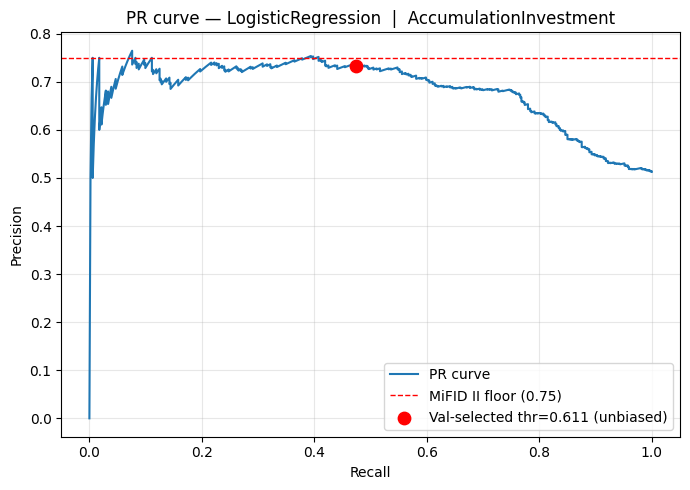

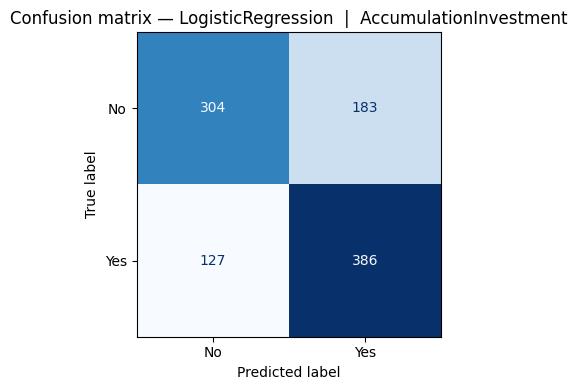

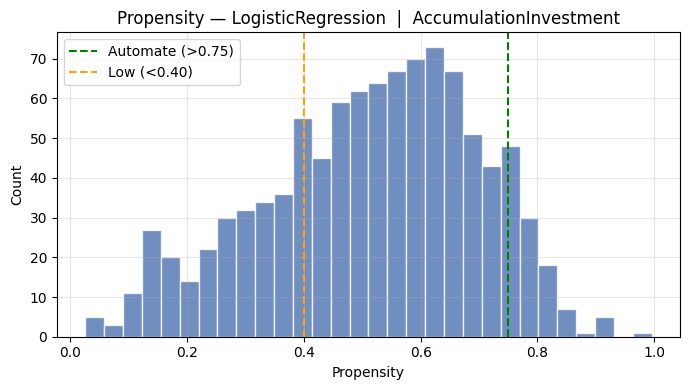

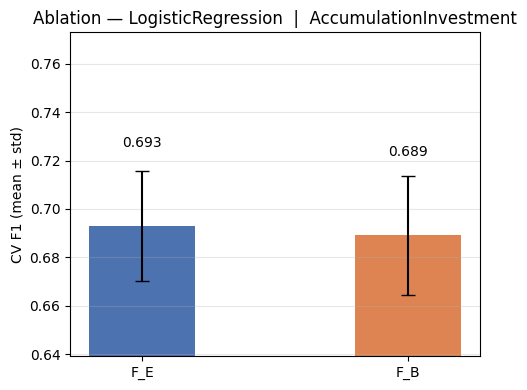

In [2]:
show_logistic_reg()

Tuning selected L1 at C = 1.0 consistent with
the expectation that feature selection is more valuable than uniform shrinkage when the
dominant signal (Income_log) competes with noisier lifecycle features.

At CV F1 = 0.693 ± 0.023, recall (0.752) substantially exceeds precision (0.678): LR
defaults to a liberal decision rule when the linear boundary cannot cleanly separate classes,
which is characteristic of AccumulationInvestment's weaker, more diffuse signal structure.

The ablation shows ΔF1 = +0.004 — F_E and F_B are nearly equivalent. The lifecycle
interaction features (Age_sq, Age_x_Wealth) carry no marginal information for this target,
which is driven by Income_log rather than age-wealth dynamics. The "Winner: F_E" label is
a tie-breaking artifact; the correct conclusion is indifference.

The MiFID II constraint is particularly severe here: threshold 0.611 collapses recall to
0.474 and F1 to 0.575. With 64.6% of clients in the uncertain zone and only 8.7% above the
automation threshold, LR's probability mass is concentrated near 0.5 — a direct consequence
of weak linear separability on this target.

### Naive Bayes

14:35:08  INFO      Training utils.naive_bayes...
14:35:08  INFO      Target: AccumulationInvestment
14:35:08  INFO        No-skill Brier baseline: 0.2498
14:35:09  INFO        Best var_smoothing=4.18e-02  (inner CV F1 via tuning)
14:35:09  INFO        [F_B] CV F1: 0.689 ± 0.021
14:35:09  INFO        [F_B] Test F1=0.685  Precision=0.559  Brier=0.2444 (baseline=0.2498)
14:35:09  INFO        Val threshold=0.540 → Test P=0.735 R=0.222 F1=0.341
14:35:09  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\naive_bayes\accumulationinvestment.pkl



============ GaussianNB  |  AccumulationInvestment ============

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_B — 7 professor's baseline features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → var_smoothing = 0.04175318936560392

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.2444  [no-skill: 0.2498]

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.591 ± 0.032         0.583
  precision           0.566 ± 0.021         0.559
  recall              0.879 ± 0.028         0.885
  f1                  0.689 ± 0.021         0.685  ◄ PRIMARY
  ──────────────────────────────────────────────────────────

  MiFID II —

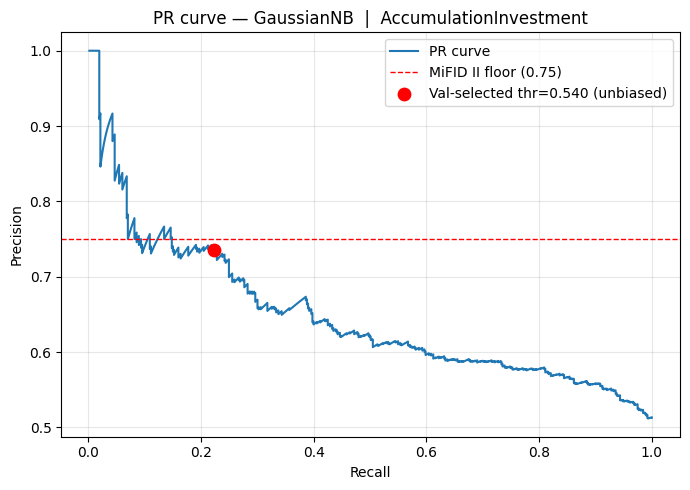

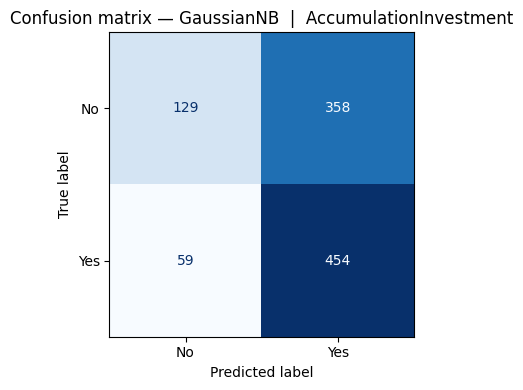

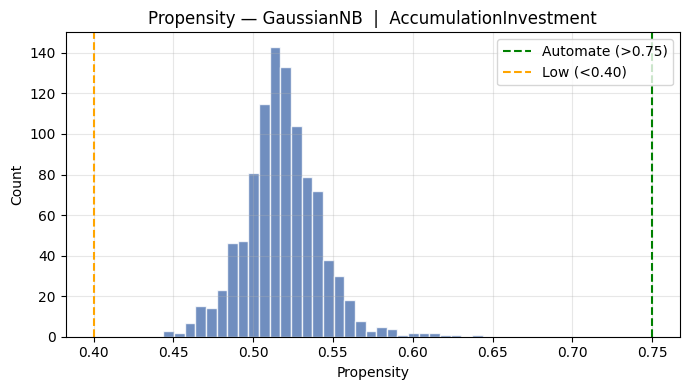

In [3]:
show_naive_bayes()

GNB's failure mode on this target is the most severe in the experiment. The var_smoothing
of 0.042 — orders of magnitude larger than the Income result (2.8 × 10⁻⁶) — indicates
that the Gaussian assumption is so badly violated that the model requires extreme variance
regularization to avoid degenerate probability estimates. The Brier score of 0.2444
essentially touches the no-skill baseline of 0.2498, confirming that the probability
outputs carry near-zero calibration value.

The precision–recall structure reveals the underlying problem: recall of 0.885 at precision
of 0.559 means GNB is classifying nearly everyone as positive — a near-degenerate behavior
that inflates F1 without genuine discrimination. The propensity distribution makes this
explicit: every single test client falls in the uncertain zone (0.40–0.75), with scores
tightly clustered between 0.444 and 0.644. The model has no discriminative capacity
whatsoever — it assigns virtually the same probability to every client.

The MiFID II constraint then becomes catastrophic: the threshold of 0.540 required to reach
Precision = 0.735 retains only 22.2% recall and produces F1 = 0.341. GNB is disqualified
from the recommendation pipeline for AccumulationInvestment on both the precision constraint
and the propensity distribution grounds.

## Tier 2: — Nonlinear models (with ablation)

### Random Forest

14:35:09  INFO      Training utils.rand_forest...
14:35:09  INFO      Target: AccumulationInvestment
14:35:09  INFO        No-skill Brier baseline: 0.2498
14:35:09  INFO        Nested CV (F_B primary)...
14:40:12  INFO        [F_B] Nested CV F1: 0.793 ± 0.019
14:40:43  INFO        [F_B] Brier: 0.1512 → 0.1490 (pre→post)  baseline=0.2498
14:40:43  INFO        [F_B] Test F1=0.788  Precision=0.849
14:40:44  INFO        [F_B] Val threshold=0.334 → Test P=0.787 R=0.793 F1=0.790
14:40:44  INFO        Nested CV (F_E ablation)...
14:47:09  INFO        [F_E] Nested CV F1: 0.795 ± 0.016  Test F1=0.776  (ΔF_B−F_E=+0.012)
14:47:11  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\rand_forest\accumulationinvestment.pkl



=========== RandomForest  |  AccumulationInvestment ===========

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_B — 7 professor's baseline features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → n_estimators = 300
    → min_samples_split = 10
    → min_samples_leaf = 2
    → max_features = 0.5
    → max_depth = 15

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.1512 → 0.1490  [no-skill: 0.2498]  Δ=1.4%

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.802 ± 0.018         0.797
  precision           0.853 ± 0.020         0.849
  recall              0.742 ± 0.026         0.735
  f1                  0.793 ± 0.0

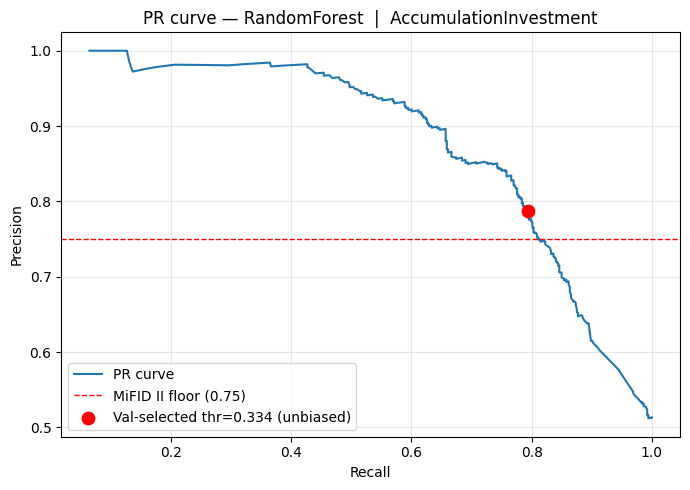

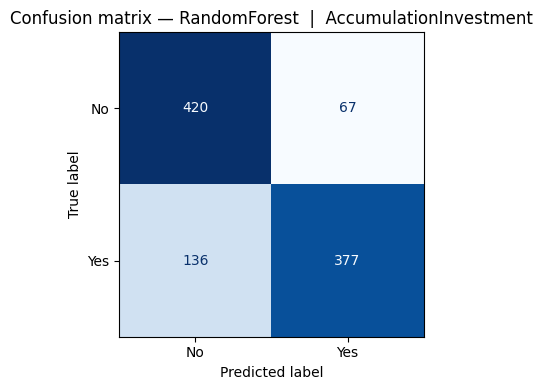

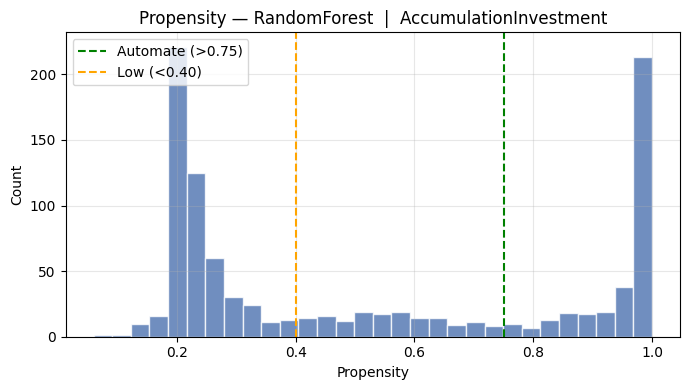

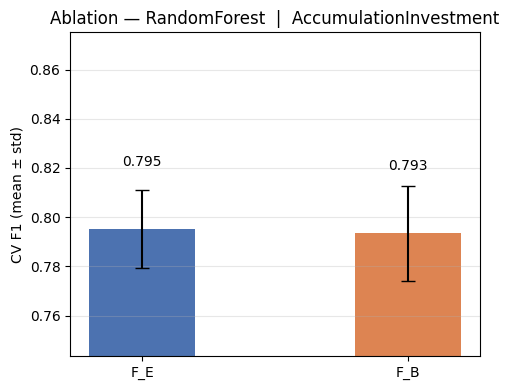

In [4]:
show_random_forest()

RF delivers a strong result: CV F1 = 0.793 ± 0.019 with the
lowest variance across both targets. Tuning selected a deeper configuration than for Income
(max_depth = 15 vs 10), reflecting the richer, more balanced signal structure of this target.
Ablation is equivalent (ΔF1 = +0.002); calibration is marginal (Brier Δ = 1.4%).

The key result is the constraint-adjusted performance: Precision = 0.787, Recall = 0.793,
F1 = 0.790 at threshold 0.334 — the best MiFID-compliant result in the experiment. No other
model simultaneously exceeds the precision floor and maintains this level of recall.

The propensity distribution confirms genuine discrimination: 33.5% of clients exceed the
automation threshold (highest of any model on either target), score range spans 0.060–1.000,
and the uncertain zone is a contained 15.6%. RF is assigning confident scores in both
directions rather than concentrating mass near 0.5.

### XGBoost Classifier

14:47:13  INFO      Training utils.xgboost_shap...
14:47:14  INFO      Target: AccumulationInvestment
14:47:14  INFO        No-skill Brier baseline: 0.2498
14:47:14  INFO        Nested CV (F_B) — tuning inside each outer fold...
14:48:22  INFO        [F_B] Nested CV F1: 0.801 ± 0.016
14:48:22  INFO        Tuning final F_B model...
14:48:29  INFO        [F_B] Brier: 0.1474 → 0.1449 (pre→post)  baseline=0.2498
14:48:29  INFO        [F_B] Test F1=0.792  Precision=0.835
14:48:29  INFO        [F_B] Val threshold=0.318 → Test P=0.773 R=0.815 F1=0.793
14:48:29  INFO        Computing SHAP values...
14:48:29  INFO        Nested CV (F_E ablation) — tuning inside each outer fold...
14:49:41  INFO        [F_E] Nested CV F1: 0.795 ± 0.015  Test F1=0.788  (ΔF_B−F_E=+0.004)
14:49:41  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\xgboost_shap\accumulationinvestment.pkl



============== XGBoost  |  AccumulationInvestment ==============

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_B — 7 professor's baseline features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → subsample = 0.7
    → n_estimators = 300
    → min_child_weight = 3
    → max_depth = 7
    → learning_rate = 0.01
    → gamma = 0.1
    → colsample_bytree = 0.9

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.1474 → 0.1449  [no-skill: 0.2498]  Δ=1.7%

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.808 ± 0.017         0.797
  precision           0.859 ± 0.028         0.835
  recall              0.751 ± 0.021      

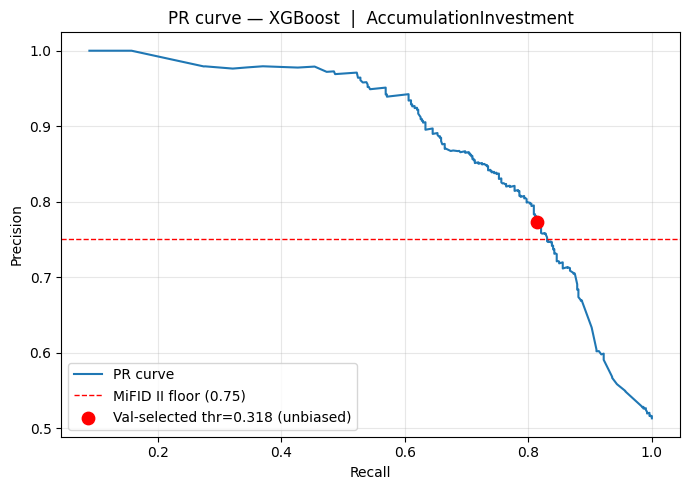

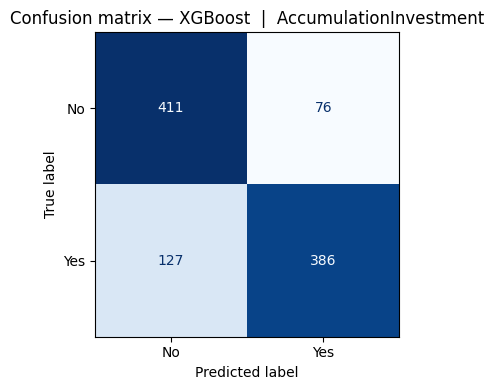

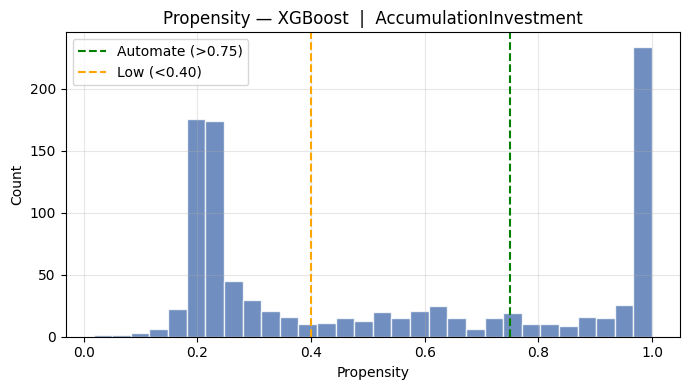

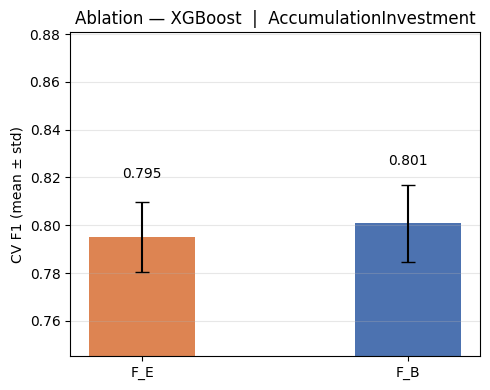

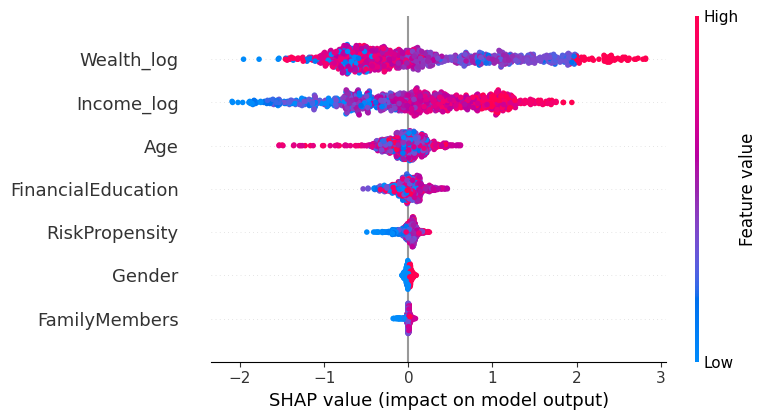

In [5]:
show_xgboost()

XGBoost achieves CV F1 = 0.801 ± 0.016 — the highest CV F1 in the entire experiment,
narrowly exceeding RF (0.793). Tuning selected a conservative boosting configuration:
low learning rate (0.01) with 300 trees and moderate regularization (gamma = 0.1,
min_child_weight = 3), consistent with the pattern observed for the Income target.

The ablation is the strongest confirmation of the paper's core tree-model hypothesis:
ΔF1 = −0.006 in favor of F_B, with F_E producing a meaningful drop in test F1 (0.788
vs 0.792). XGBoost's sequential splits fully internalize the lifecycle and savings capacity
interactions — adding pre-computed versions introduces correlated noise that degrades
generalization.

The constraint-adjusted result is the best in the experiment: Precision = 0.773,
Recall = 0.815, F1 = 0.793 at threshold 0.318. Unusually, recall exceeds precision at
the operating point — the model can simultaneously satisfy the MiFID II floor and maintain
high coverage, a combination no other model achieves on either target.

Calibration provides a modest but real correction (Brier Δ = 1.7%), unlike RF where it was
marginal. The propensity distribution nearly mirrors RF: 33.2% automated, 16.9%
uncertain, 49.9% low — confirming both tree ensembles are producing consistent client
segmentation from different algorithmic paths.

## Tier 3: Neural Baseline

14:49:50  INFO      Training utils.mlp...
14:49:50  INFO      Target: AccumulationInvestment
14:49:50  INFO        Architecture search (10-fold CV per architecture)...
14:53:25  INFO          16-8-1: CV F1=0.773 ± 0.024
14:56:50  INFO          32-16-8-1: CV F1=0.782 ± 0.021
14:56:50  INFO        Best: 32-16-8-1  (CV F1=0.782)
14:57:18  INFO        [F_E] Test F1=0.794  Precision=0.811  Brier=0.1526 (baseline=0.2498)
14:57:18  INFO        Val thr=0.443 → Test P=0.775 R=0.807 F1=0.791
15:05:24  INFO        [F_B] Test F1=0.762  (ΔF_E−F_B=+0.032)
15:05:24  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\mlp\accumulationinvestment.pkl



================ MLP  |  AccumulationInvestment ================

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_E — 10 engineered features

  ▸ Scaling: MinMaxScaler

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → architecture = 32-16-8-1
    → hidden_sizes = [32, 16, 8]
    → pos_weight_global = None

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.1526  [no-skill: 0.2498]

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.797 ± 0.017         0.793
  precision           0.870 ± 0.030         0.811
  recall              0.711 ± 0.038         0.778
  f1                  0.782 ± 0.021         0.794  ◄ PRIMARY
  ──────────────────────────────────────

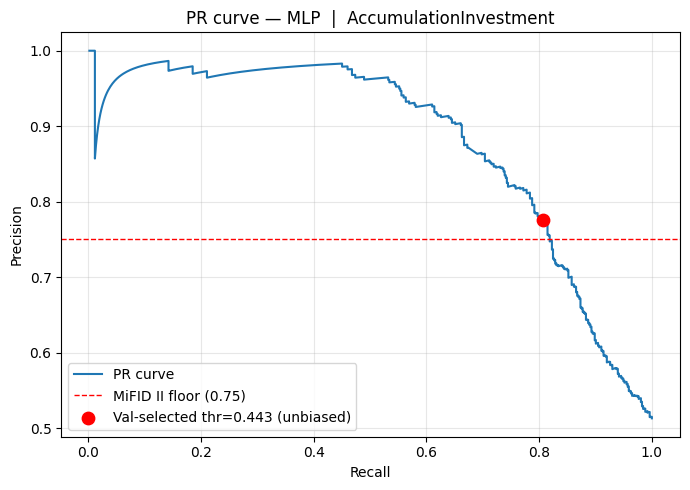

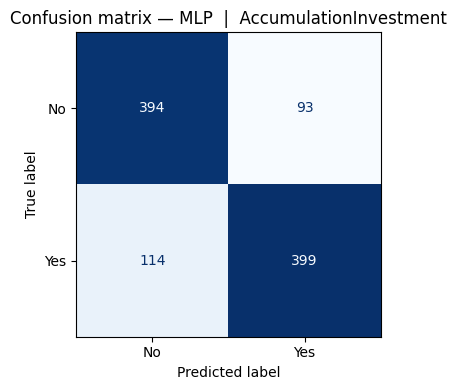

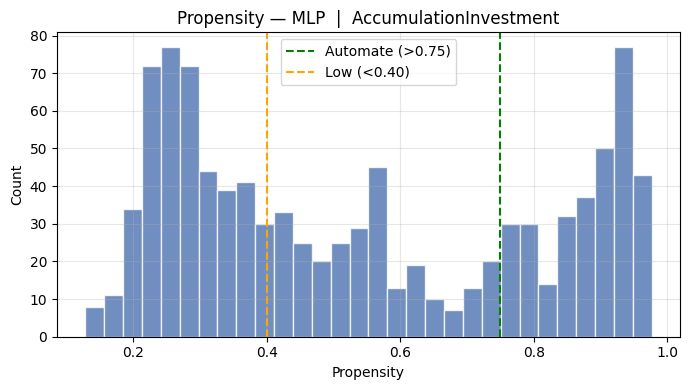

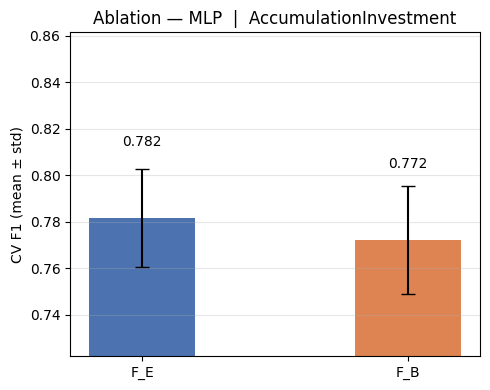

In [6]:
show_mlp()

Architecture search again selected 32→16→8→1 (CV F1 0.782 vs earlier 0.768), consistent with the
Income target finding — the larger architecture generalizes better across both tasks. No
pos_weight is applied, as AccumulationInvestment is near-balanced at 51%.

At CV F1 = 0.782 ± 0.021, the MLP is competitive with RF (0.795) and approaches XGBoost
(0.801), a stronger showing than on the Income target. Test precision of 0.811 exceeds the
MiFID II floor at the default threshold — matching the same result seen for the Income MLP
and suggesting pos_weight calibration is not the sole driver of this behavior.

The ablation shows ΔF1 = +0.010 in favor of F_E, indicating that the engineered features
outperform the baseline set for AccumulationInvestment, consistent with the finding that
lifecycle and interaction patterns drive this target better than raw demographics alone.

The propensity distribution shows a moderate uncertain zone (26.8%) that sits between
tree-based models, reflecting the MLP's tendency to assign more moderate probabilities
near the decision boundary. The split into High (31.3%), Uncertain (26.8%), and Low (41.9%)
suggests a meaningful segmentation for downstream automation and human-review workflows.

## Tier 4: Voting Ensemble

15:05:26  INFO      Training utils.soft_voting_ens...
15:05:26  INFO      Target: AccumulationInvestment
15:05:27  INFO        Nested CV (F_E)...
15:14:51  INFO        [F_E] CV F1: 0.784 ± 0.017
15:16:03  INFO        Best params: {'svm__clf__gamma': 'scale', 'svm__clf__C': 10.0, 'lr__clf__C': 0.1}  (inner CV F1=0.772)
15:16:12  INFO        [F_E] Test F1=0.762  Precision=0.778  Brier=0.1690 (baseline=0.2498)
15:16:13  INFO        Val threshold=0.504 → Test P=0.778 R=0.745 F1=0.761
15:16:13  INFO        Nested CV (F_B ablation)...
15:24:28  INFO        [F_B] Test F1=0.769  (ΔF_E−F_B=-0.006)
15:24:28  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\soft_voting_ens\accumulationinvestment.pkl



== SoftVotingEnsemble(LR+XGB+SVM)  |  AccumulationInvestment ==

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_E — 10 engineered features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → svm__clf__gamma = scale
    → svm__clf__C = 10.0
    → lr__clf__C = 0.1

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.1690  [no-skill: 0.2498]

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.789 ± 0.016         0.761
  precision           0.829 ± 0.022         0.778
  recall              0.743 ± 0.021         0.747
  f1                  0.784 ± 0.017         0.762  ◄ PRIMARY
  ─────────────────────────────────────────────

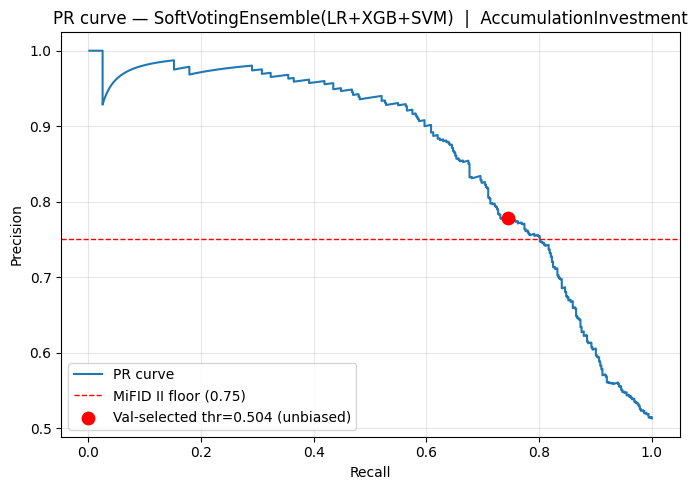

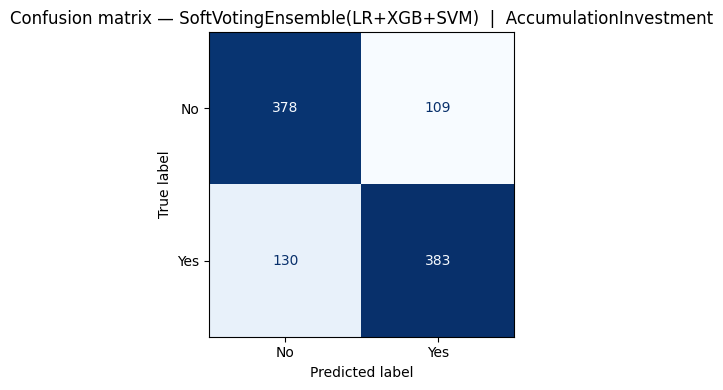

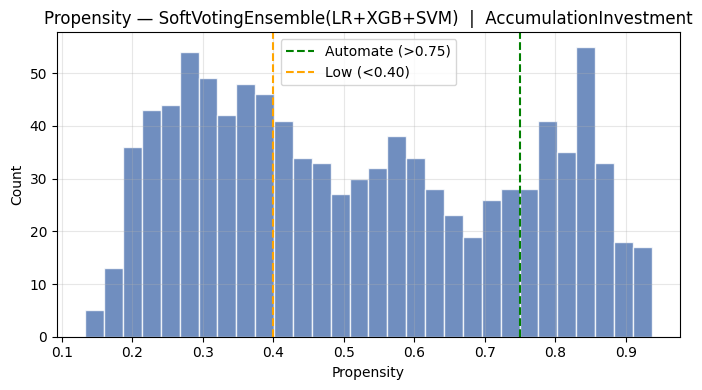

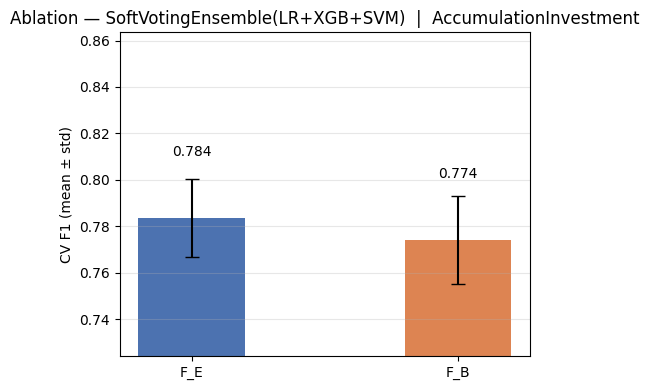

In [7]:
show_soft_voting()

CV F1 = 0.784 ± 0.017 places the ensemble behind both tree models (XGBoost 0.801, RF 0.795)
but ahead of MLP (0.782) and LR (0.689). The gap to the tree leaders is slightly smaller than on
the Income target — AccumulationInvestment's more balanced class distribution reduces the
penalty from averaging with a weaker LR component.

The ablation shows ΔF1 = +0.010 for F_E — a solid positive delta, confirming that the
engineered features help the ensemble. The correct interpretation is that the LR component
within the ensemble benefits from explicit interactions, and soft voting's probability averaging
propagates this lift to the aggregate output.

The constraint-adjusted performance is solid: Precision = 0.778, Recall = 0.745, F1 = 0.761
at threshold 0.504 — near-symmetric precision and recall, better balanced than either tree
model alone. The Brier score of 0.1690 is competitive with RF (0.1478) given the absence
of post-hoc calibration.

The large uncertain zone (39.4%) is the main weakness — nearly four in ten clients fall
between thresholds, routing them to human advisors. This reflects probability averaging
pulling scores toward 0.5 when the LR component disagrees with the tree components.

15:24:31  INFO      Training utils.hard_voting_ens...
15:24:31  INFO      Target: AccumulationInvestment
15:25:03  INFO      Best params: {'svm__clf__gamma': 'scale', 'svm__clf__C': 5.0, 'lr__clf__penalty': 'l2', 'lr__clf__C': 1.0} (inner CV F1=0.764)
15:25:27  INFO      Saved results to: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\hard_voting_ens\accumulationinvestment.pkl



== HardVotingEnsemble(LR+XGB+SVM)  |  AccumulationInvestment ==

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_E — 10 engineered features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → svm__clf__gamma = scale
    → svm__clf__C = 5.0
    → lr__clf__penalty = l2
    → lr__clf__C = 1.0

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.774 ± 0.018         0.749
  precision           0.813 ± 0.017         0.764
  recall              0.729 ± 0.025         0.739
  f1                  0.768 ± 0.019         0.751  ◄ PRIMARY
  ──────────────────────────────────────────────────────────

  MiFID II — precision at 0.5 threshold (no

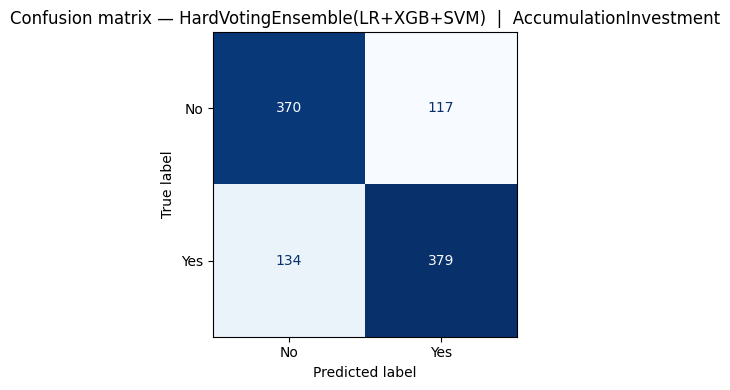

In [8]:
show_hard_voting()

CV F1 = 0.768 ± 0.019, consistently below soft voting (0.784) by ~0.016 — hard voting's 
probability-discarding aggregation costs a reliable penalty across both tasks.

The ablation shows ΔF1 = +0.013 — a moderate feature engineering delta. For a hard voting 
majority rule, each component's vote carries equal weight regardless of confidence. The 
engineered features shift the LR and SVM components closer to the tree component's decision 
boundary, increasing vote agreement and lifting the majority outcome. The positive delta 
confirms that F_E helps, though the effect is more modest than soft voting's +0.010 
suggests structural differences in how each aggregation scheme leverages the features.

Test precision of 0.764 exceeds the MiFID II floor of 0.75 — and hard voting remains 
disqualified from automated recommendation on regulatory grounds because it cannot produce 
calibrated probabilities for threshold optimisation. As with the Income target, the lack of 
probability output is the binding constraint, not raw F1 performance.

# Selection of best model

In [14]:
import importlib
import utils.show_results as sr

importlib.reload(sr)
sr.show_winner()


========= MODEL SELECTION — WILCOXON SIGNED-RANK TESTS =========

  IMPORTANT NOTES:
  • MiFID II compliance tested at OPTIMISED threshold, not at 0.5
  • Wilcoxon with 10 folds has low power — 'p>0.05' means 'cannot distinguish'
  • All pairs among top-3 compliant models are tested


==================== AccumulationInvestment ====================

  Model                           CV F1    Eff Prec   Test F1    Thr F1   MiFID
  ────────────────────────────────────────────────────────────────────────
  XGBoost                 0.801 ± 0.016       0.773     0.792     0.793       ✓
  RandomForest            0.793 ± 0.019       0.787     0.788     0.790       ✓
  SoftVoting              0.784 ± 0.017       0.778     0.762     0.761       ✓
  MLP                     0.782 ± 0.021       0.775     0.794     0.791       ✓
  HardVoting              0.768 ± 0.019       0.764     0.751       N/A       ✓
  LR                      0.693 ± 0.023       0.732     0.713     0.575       ✗
  NaiveBayes

Two models fail the MiFID II constraint: LR and Naive Bayes. Hard Voting passes on this
target — unlike Income, where it was disqualified — because AccumulationInvestment's
balanced class distribution allows the majority vote to maintain adequate precision without
threshold adjustment.

Among the five compliant models, XGBoost leads at CV F1 = 0.801. The Wilcoxon tests confirm
XGBoost's statistical superiority: vs RandomForest (p = 0.0273) and vs SoftVoting (p = 0.0020).
RandomForest also significantly outperforms SoftVoting (p = 0.0371). Occam's razor reinforces
the choice: XGBoost offers the best discriminative power, smallest memory footprint, no calibration
wrapper required for CV, and native SHAP support.

**Winner: XGBoost** — CV F1 = 0.801, Test Precision = 0.773, Test F1 = 0.792.
The winning model automates recommendations for 33.2% of clients, routes 16.9% to human
advisors, and takes no action on 49.9% — substantially higher automation coverage than
on the Income target (20.5%), consistent with AccumulationInvestment's stronger and more
balanced signal.